# Cross-Vintage Validation: Profit Scoring vs Default Scoring vs LC Grade

Out-of-time backtest across 4 independent test cohorts (2012–2015).  
Each cohort uses only loans issued **before** the test year to train all models.

| Vintage | Train size | Test size | Matured | Notes |
|---|---|---|---|---|
| 2012 | 42,535 | 53,367 | **100%** | All loans fully seasoned |
| 2013 | 95,902 | 134,793 | **100%** | All loans fully seasoned |
| 2014 | 230,695 | 170,643 | 77% | Matured-only backtest |
| 2015 | 452,163 | 282,853 | 75% | Matured-only backtest |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

REPORTS = Path('../reports')

POLICY_COLORS = {
    'profit_scoring':  '#2196F3',   # blue
    'default_scoring': '#FF9800',   # orange
    'grade_only':      '#9E9E9E',   # grey
    'invest_all':      '#4CAF50',   # green (dashed)
}
POLICY_LABELS = {
    'profit_scoring':  'Profit Scoring (ANR model)',
    'default_scoring': 'Default Scoring (PD model)',
    'grade_only':      'LC Grade Only (benchmark)',
    'invest_all':      'Invest All (passive baseline)',
}

In [2]:
# ── Load all 8 return curve files ─────────────────────────────────────────────
FILE_MAP = [
    # (year, variant_label, suffix, matured_pct, test_n, capital_m)
    (2012, 'Grade-Blind', '_2012',            100, 53_367,  718),
    (2012, 'Grade-Aware', '_with_grade_2012', 100, 53_367,  718),
    (2013, 'Grade-Blind', '_2013',            100, 134_793, 1982),
    (2013, 'Grade-Aware', '_with_grade_2013', 100, 134_793, 1982),
    (2014, 'Grade-Blind', '_2014',             77, 170_643, 2203),
    (2014, 'Grade-Aware', '_with_grade_2014',  77, 170_643, 2203),
    (2015, 'Grade-Blind', '',                  75, 282_853, 3622),
    (2015, 'Grade-Aware', '_with_grade',       75, 282_853, 3622),
]

# invest_all ANR from cross_vintage_results.txt
INVEST_ALL_ANR = {2012: 0.0112, 2013: 0.0258, 2014: 0.0212, 2015: 0.0056}

dfs = []
for year, variant, suffix, mat_pct, test_n, cap_m in FILE_MAP:
    path = REPORTS / f'return_curve{suffix}.csv'
    if not path.exists():
        print(f'MISSING: {path.name}')
        continue
    df = pd.read_csv(path)
    df['vintage']    = year
    df['variant']    = variant
    df['matured_pct']= mat_pct
    df['capital_m']  = cap_m
    df['invest_all_anr'] = INVEST_ALL_ANR[year]
    # dollar return relative to invest_all at same budget
    ia_total = df.groupby('policy')['total_dollar_return'].transform(lambda x: x.iloc[-1])
    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(master):,} curve rows across {master.groupby(["vintage","variant"]).ngroups} runs')
print(master.groupby(['vintage','variant','policy']).size().to_string())

Loaded 2,400 curve rows across 8 runs
vintage  variant      policy         
2012     Grade-Aware  default_scoring    100
                      grade_only         100
                      profit_scoring     100
         Grade-Blind  default_scoring    100
                      grade_only         100
                      profit_scoring     100
2013     Grade-Aware  default_scoring    100
                      grade_only         100
                      profit_scoring     100
         Grade-Blind  default_scoring    100
                      grade_only         100
                      profit_scoring     100
2014     Grade-Aware  default_scoring    100
                      grade_only         100
                      profit_scoring     100
         Grade-Blind  default_scoring    100
                      grade_only         100
                      profit_scoring     100
2015     Grade-Aware  default_scoring    100
                      grade_only         100
                      pr

In [3]:
def get_at(df, vintage, variant, policy, frac):
    """Interpolate port_anr and total_dollar_return at a specific budget fraction."""
    sub = df[(df['vintage']==vintage) & (df['variant']==variant) & (df['policy']==policy)]
    if sub.empty:
        return np.nan, np.nan
    idx = (sub['fraction_invested'] - frac).abs().idxmin()
    row = sub.loc[idx]
    return row['port_anr'], row['total_dollar_return']

## Figure 1: Return Curves — All 4 Vintages (Grade-Blind Variant)

Each panel is a completely independent out-of-time backtest.  
X axis = fraction of loans funded (budget).  Y axis = realized annualized portfolio return.

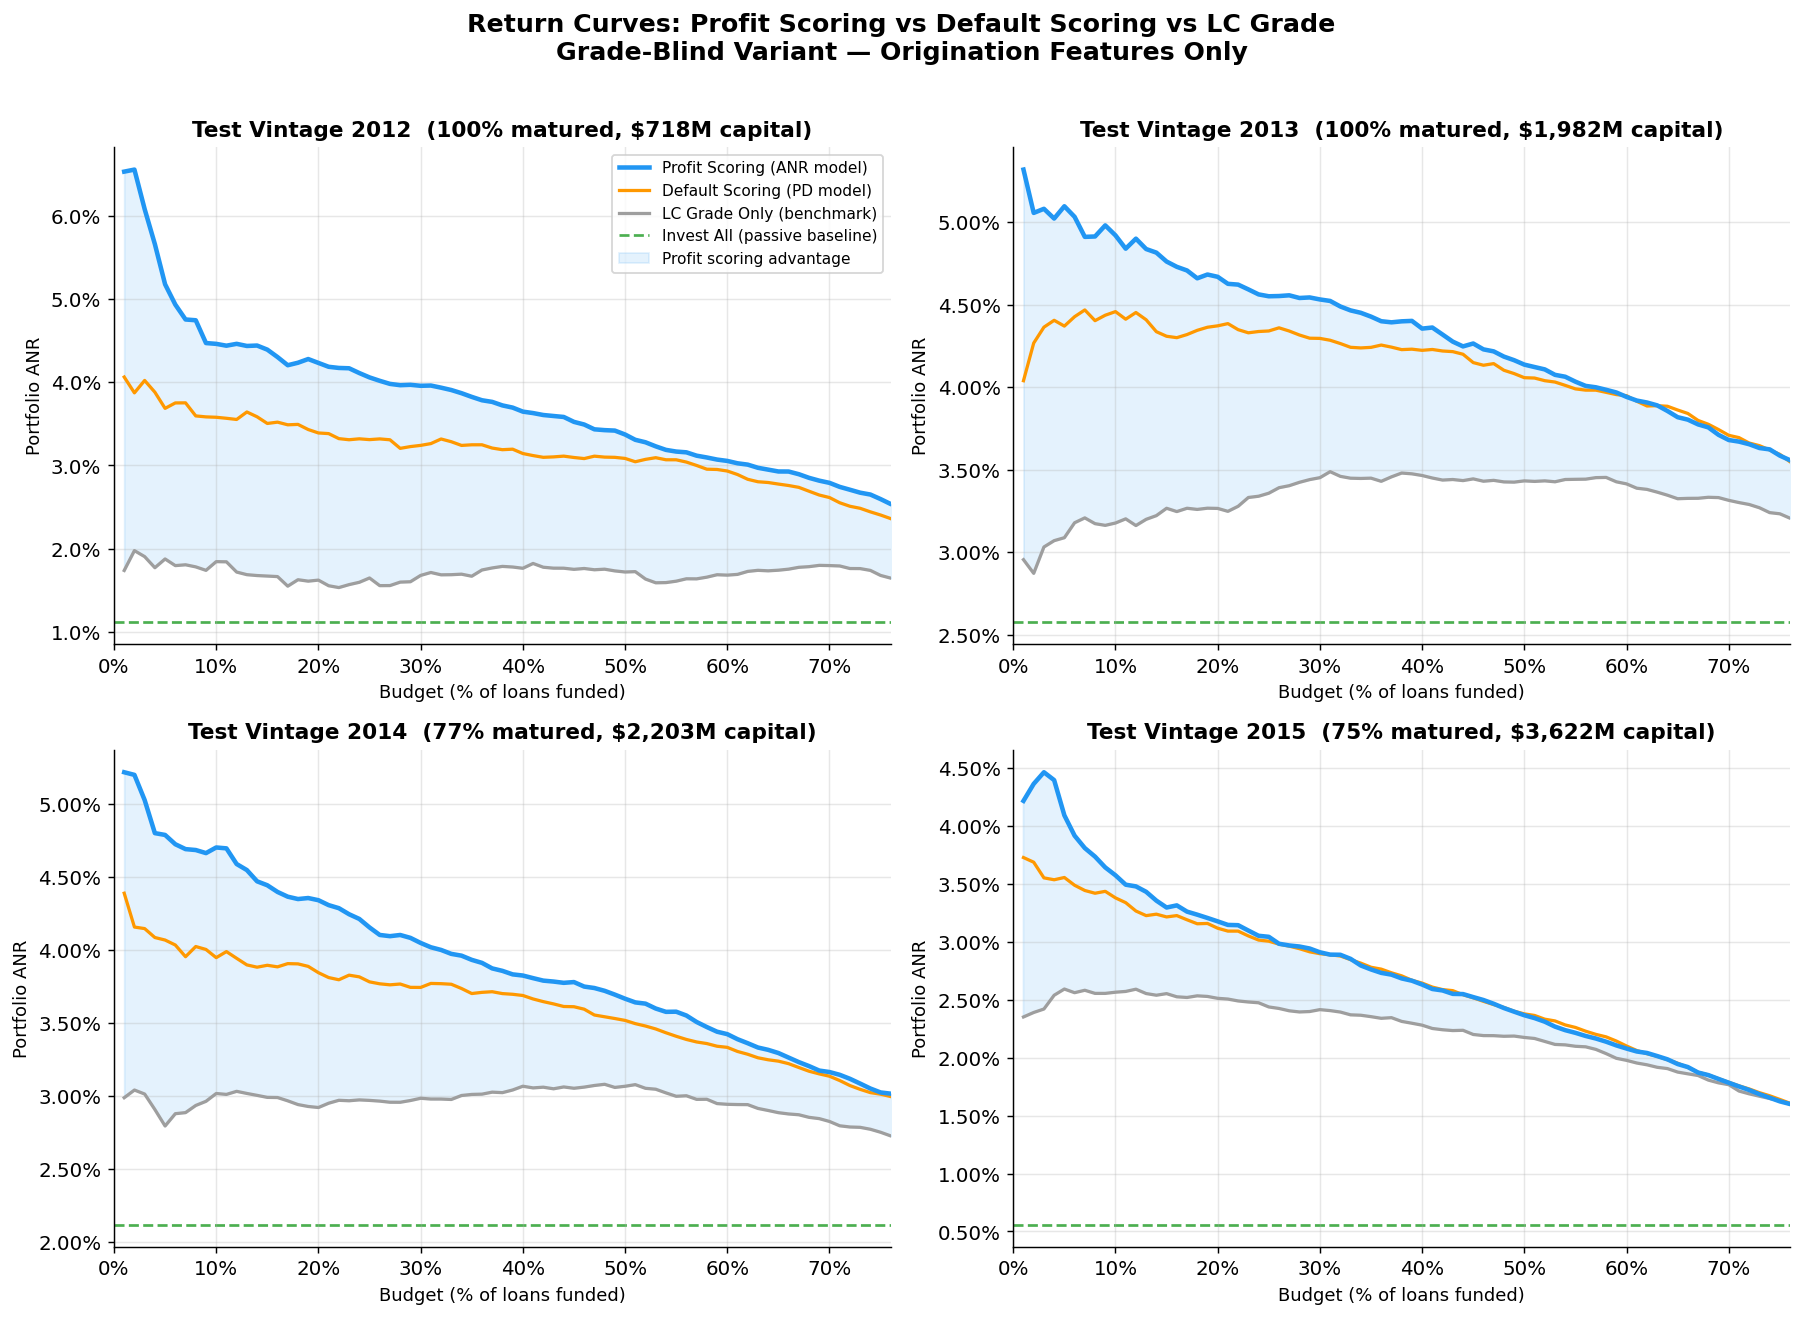

In [4]:
VINTAGES = [2012, 2013, 2014, 2015]
POLICIES_PLOT = ['profit_scoring', 'default_scoring', 'grade_only']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for ax, year in zip(axes, VINTAGES):
    sub = master[(master['vintage'] == year) & (master['variant'] == 'Grade-Blind')]
    ia  = INVEST_ALL_ANR[year]
    cap = FILE_MAP[[r[0] for r in FILE_MAP].index(year)][5] if year in [r[0] for r in FILE_MAP] else 0
    mat = [r[3] for r in FILE_MAP if r[0]==year and r[1]=='Grade-Blind'][0]

    for policy in POLICIES_PLOT:
        pdata = sub[sub['policy'] == policy]
        if pdata.empty:
            continue
        ax.plot(
            pdata['fraction_invested'] * 100,
            pdata['port_anr'] * 100,
            color=POLICY_COLORS[policy],
            linewidth=2.5 if policy == 'profit_scoring' else 1.8,
            label=POLICY_LABELS[policy],
            zorder=3 if policy == 'profit_scoring' else 2,
        )

    ax.axhline(ia * 100, color=POLICY_COLORS['invest_all'],
               linestyle='--', linewidth=1.5, label=POLICY_LABELS['invest_all'], zorder=1)

    # shade profit_scoring advantage over grade_only
    ps_data  = sub[sub['policy'] == 'profit_scoring'].set_index('fraction_invested')['port_anr']
    go_data  = sub[sub['policy'] == 'grade_only'].set_index('fraction_invested')['port_anr']
    common_x = np.intersect1d(ps_data.index, go_data.index)
    if len(common_x) > 0:
        x_pct = common_x * 100
        ax.fill_between(x_pct,
                        go_data[common_x].values * 100,
                        ps_data[common_x].values * 100,
                        where=(ps_data[common_x].values > go_data[common_x].values),
                        alpha=0.12, color='#2196F3', label='Profit scoring advantage')

    ax.set_xlim(0, 76)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Budget (% of loans funded)', fontsize=10)
    ax.set_ylabel('Portfolio ANR', fontsize=10)
    ax.set_title(f'Test Vintage {year}  ({mat}% matured, ${cap:,}M capital)', fontsize=12, fontweight='bold')
    if year == 2012:
        ax.legend(fontsize=8.5, loc='upper right')

fig.suptitle('Return Curves: Profit Scoring vs Default Scoring vs LC Grade\n'
             'Grade-Blind Variant — Origination Features Only', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS / 'fig1_return_curves_all_vintages.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 2: Profit Scoring Advantage Over Grade-Only — Across All Vintages

How many basis points does profit scoring beat LC's own grade at each budget level?  
Consistent positive values across all 4 lines = the finding is not a one-year fluke.

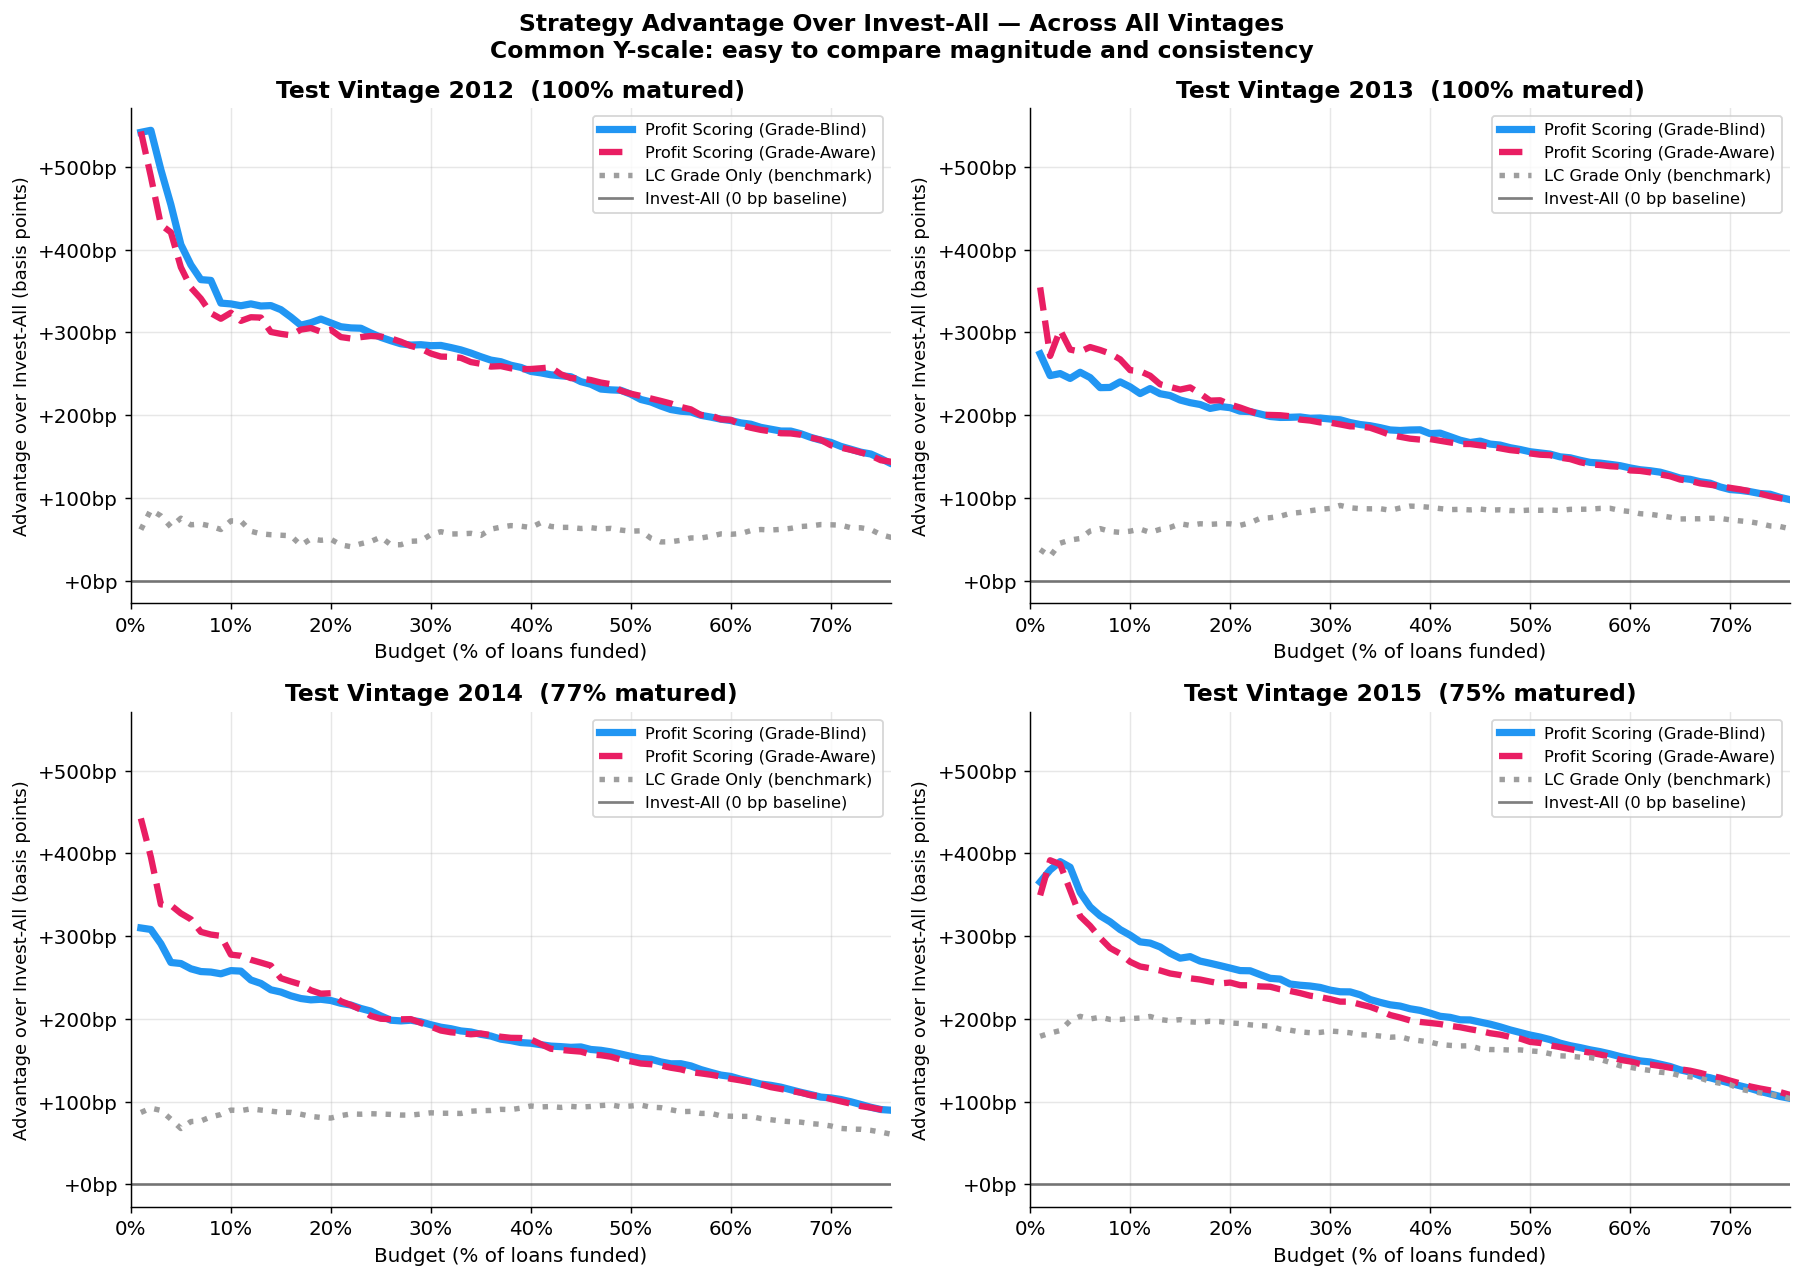

In [5]:
VINTAGE_COLORS = {2012: '#E53935', 2013: '#8E24AA', 2014: '#00897B', 2015: '#1E88E5'}
VINTAGE_STYLES = {2012: '-', 2013: '--', 2014: '-.', 2015: ':'}

STRATEGIES = [
    # (variant,       policy,            label,                       color,     ls,   lw)
    ('Grade-Blind', 'profit_scoring',  'Profit Scoring (Grade-Blind)', '#2196F3', '-',  4.0),
    ('Grade-Aware', 'profit_scoring',  'Profit Scoring (Grade-Aware)', '#E91E63', '--', 3.5),
    ('Grade-Blind', 'grade_only',      'LC Grade Only (benchmark)',    '#9E9E9E', ':',  3.0),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, year in zip(axes, VINTAGES):
    ia  = INVEST_ALL_ANR[year]
    mat = [r[3] for r in FILE_MAP if r[0]==year and r[1]=='Grade-Blind'][0]

    for variant, policy, label, color, ls, lw in STRATEGIES:
        sub = master[(master['vintage']==year) & (master['variant']==variant) & (master['policy']==policy)]
        if sub.empty:
            continue
        ax.plot(sub['fraction_invested'] * 100,
                (sub['port_anr'] - ia) * 10000,
                color=color, linestyle=ls, linewidth=lw, label=label)

    ax.axhline(0, color='black', linewidth=1.5, alpha=0.5, linestyle='-', label='Invest-All (0 bp baseline)')
    ax.set_xlim(0, 76)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'+{int(x)}bp' if x >= 0 else f'{int(x)}bp'))
    ax.set_xlabel('Budget (% of loans funded)', fontsize=11)
    ax.set_ylabel('Advantage over Invest-All (basis points)', fontsize=10)
    ax.set_title(f'Test Vintage {year}  ({mat}% matured)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

# Shared Y axis across all 4 panels
all_lo = min(ax.get_ylim()[0] for ax in axes)
all_hi = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(all_lo, all_hi)

fig.suptitle('Strategy Advantage Over Invest-All — Across All Vintages\n'
             'Common Y-scale: easy to compare magnitude and consistency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'fig2_advantage_over_grade.png', bbox_inches='tight', dpi=150)
plt.show()


## Figure 3: Bar Chart — Portfolio ANR at Fixed Budgets

Comparing all 4 policies at 3% and 25% budgets across all vintages.  
3% = focused high-conviction portfolio. 25% = broad deployment.

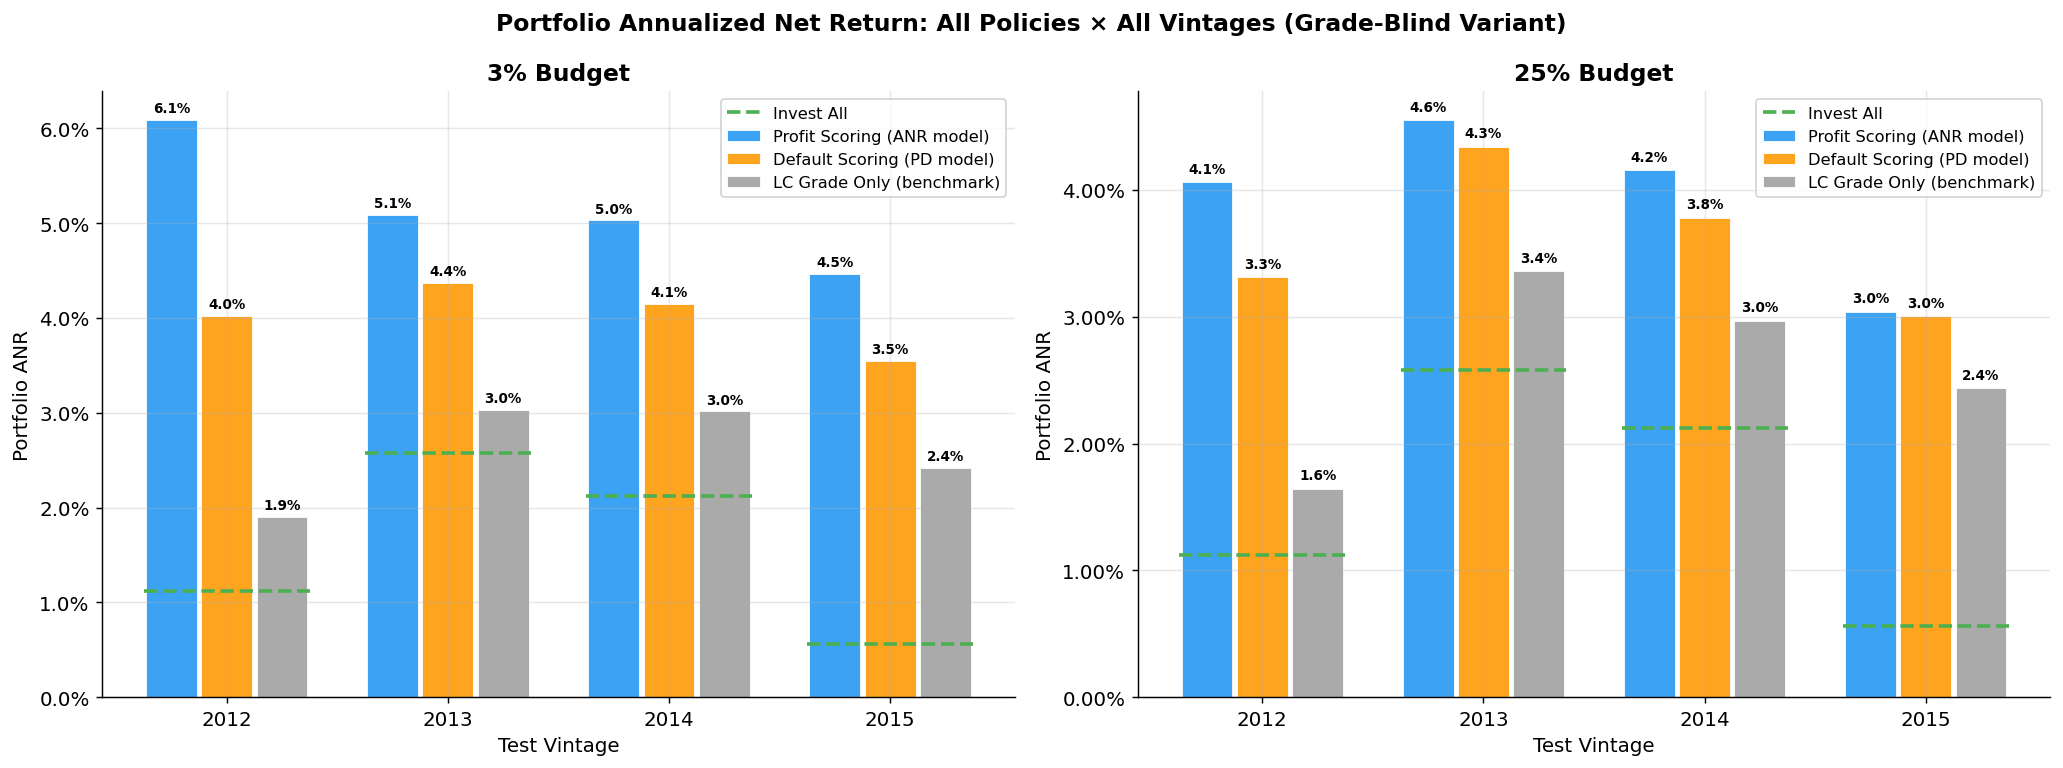

In [6]:
BUDGETS_PLOT = [0.03, 0.25]
BUDGET_LABELS = {0.03: '3% Budget', 0.25: '25% Budget'}
POLICIES_BAR = ['profit_scoring', 'default_scoring', 'grade_only']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, budget in zip(axes, BUDGETS_PLOT):
    n_vintages = len(VINTAGES)
    n_policies = len(POLICIES_BAR)
    group_w = 0.75
    bar_w   = group_w / n_policies
    x       = np.arange(n_vintages)

    for i, policy in enumerate(POLICIES_BAR):
        vals = []
        for year in VINTAGES:
            anr, _ = get_at(master, year, 'Grade-Blind', policy, budget)
            vals.append(anr * 100 if not np.isnan(anr) else 0)
        offset = (i - n_policies / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w * 0.92,
                      color=POLICY_COLORS[policy], label=POLICY_LABELS[policy],
                      alpha=0.88, edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{v:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    # invest_all as dashed horizontal per vintage
    for j, year in enumerate(VINTAGES):
        ia = INVEST_ALL_ANR[year] * 100
        ax.plot([x[j] - group_w/2, x[j] + group_w/2], [ia, ia],
                color=POLICY_COLORS['invest_all'], linewidth=2, linestyle='--',
                label='Invest All' if j == 0 else '_')

    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in VINTAGES], fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Test Vintage', fontsize=11)
    ax.set_ylabel('Portfolio ANR', fontsize=11)
    ax.set_title(BUDGET_LABELS[budget], fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Portfolio Annualized Net Return: All Policies × All Vintages (Grade-Blind Variant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'fig3_bar_policy_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 4: Dollar Profit Uplift vs LC Grade

Given a fixed budget (same number of loans funded), how many **more dollars** does  
profit scoring return compared to simply following LC's grade ordering?

> `dollar_uplift = total_dollar_return(profit_scoring, k) − total_dollar_return(grade_only, k)`
> where k = same number of loans at the same budget fraction.

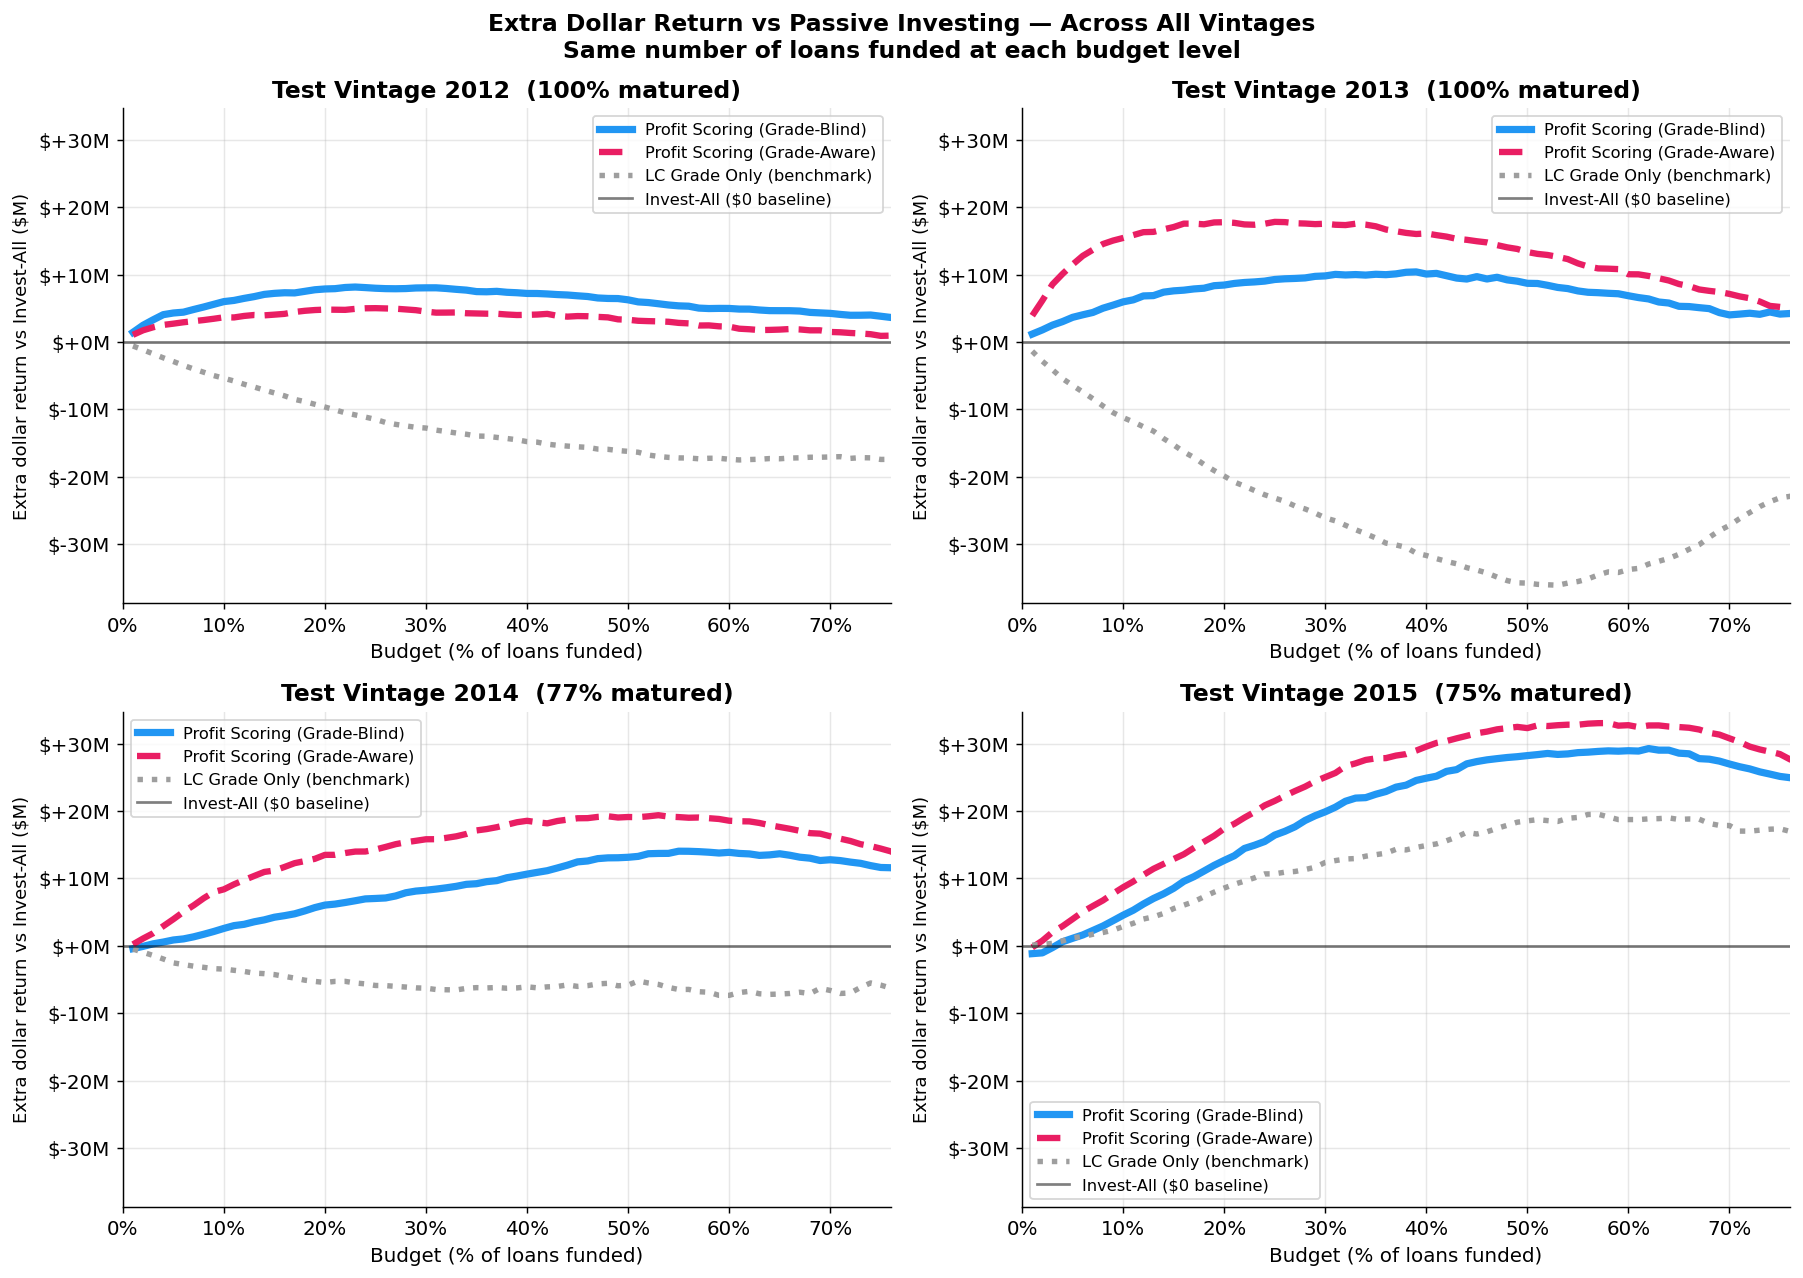

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, year in zip(axes, VINTAGES):
    mat = [r[3] for r in FILE_MAP if r[0]==year and r[1]=='Grade-Blind'][0]

    # full-book dollar return (same for all policies at fraction=1.0)
    ref = master[(master['vintage']==year) & (master['variant']=='Grade-Blind') & (master['policy']=='grade_only')]
    full_book_dollar = ref['total_dollar_return'].iloc[-1]

    for variant, policy, label, color, ls, lw in STRATEGIES:
        sub = master[(master['vintage']==year) & (master['variant']==variant) & (master['policy']==policy)]
        if sub.empty:
            continue
        fracs  = sub['fraction_invested'].values
        strat_dollar = sub['total_dollar_return'].values
        ia_dollar    = fracs * full_book_dollar          # invest-all expected at same budget
        uplift_m     = (strat_dollar - ia_dollar) / 1e6
        ax.plot(fracs * 100, uplift_m,
                color=color, linestyle=ls, linewidth=lw, label=label)

    ax.axhline(0, color='black', linewidth=1.5, alpha=0.5, linestyle='-', label='Invest-All ($0 baseline)')
    ax.set_xlim(0, 76)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+.0f}M'))
    ax.set_xlabel('Budget (% of loans funded)', fontsize=11)
    ax.set_ylabel('Extra dollar return vs Invest-All ($M)', fontsize=10)
    ax.set_title(f'Test Vintage {year}  ({mat}% matured)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)

# Shared Y axis across all 4 panels
all_lo = min(ax.get_ylim()[0] for ax in axes)
all_hi = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(all_lo, all_hi)

fig.suptitle('Extra Dollar Return vs Passive Investing — Across All Vintages\n'
             'Same number of loans funded at each budget level',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'fig4_dollar_uplift_vs_grade.png', bbox_inches='tight', dpi=150)
plt.show()


## Figure 5: Grade-Blind vs Grade-Aware — Does Knowing LC's Rate Help?

Comparing the two model variants. If Grade-Aware ≈ Grade-Blind, the models  
have already extracted the pricing signal from borrower characteristics alone.

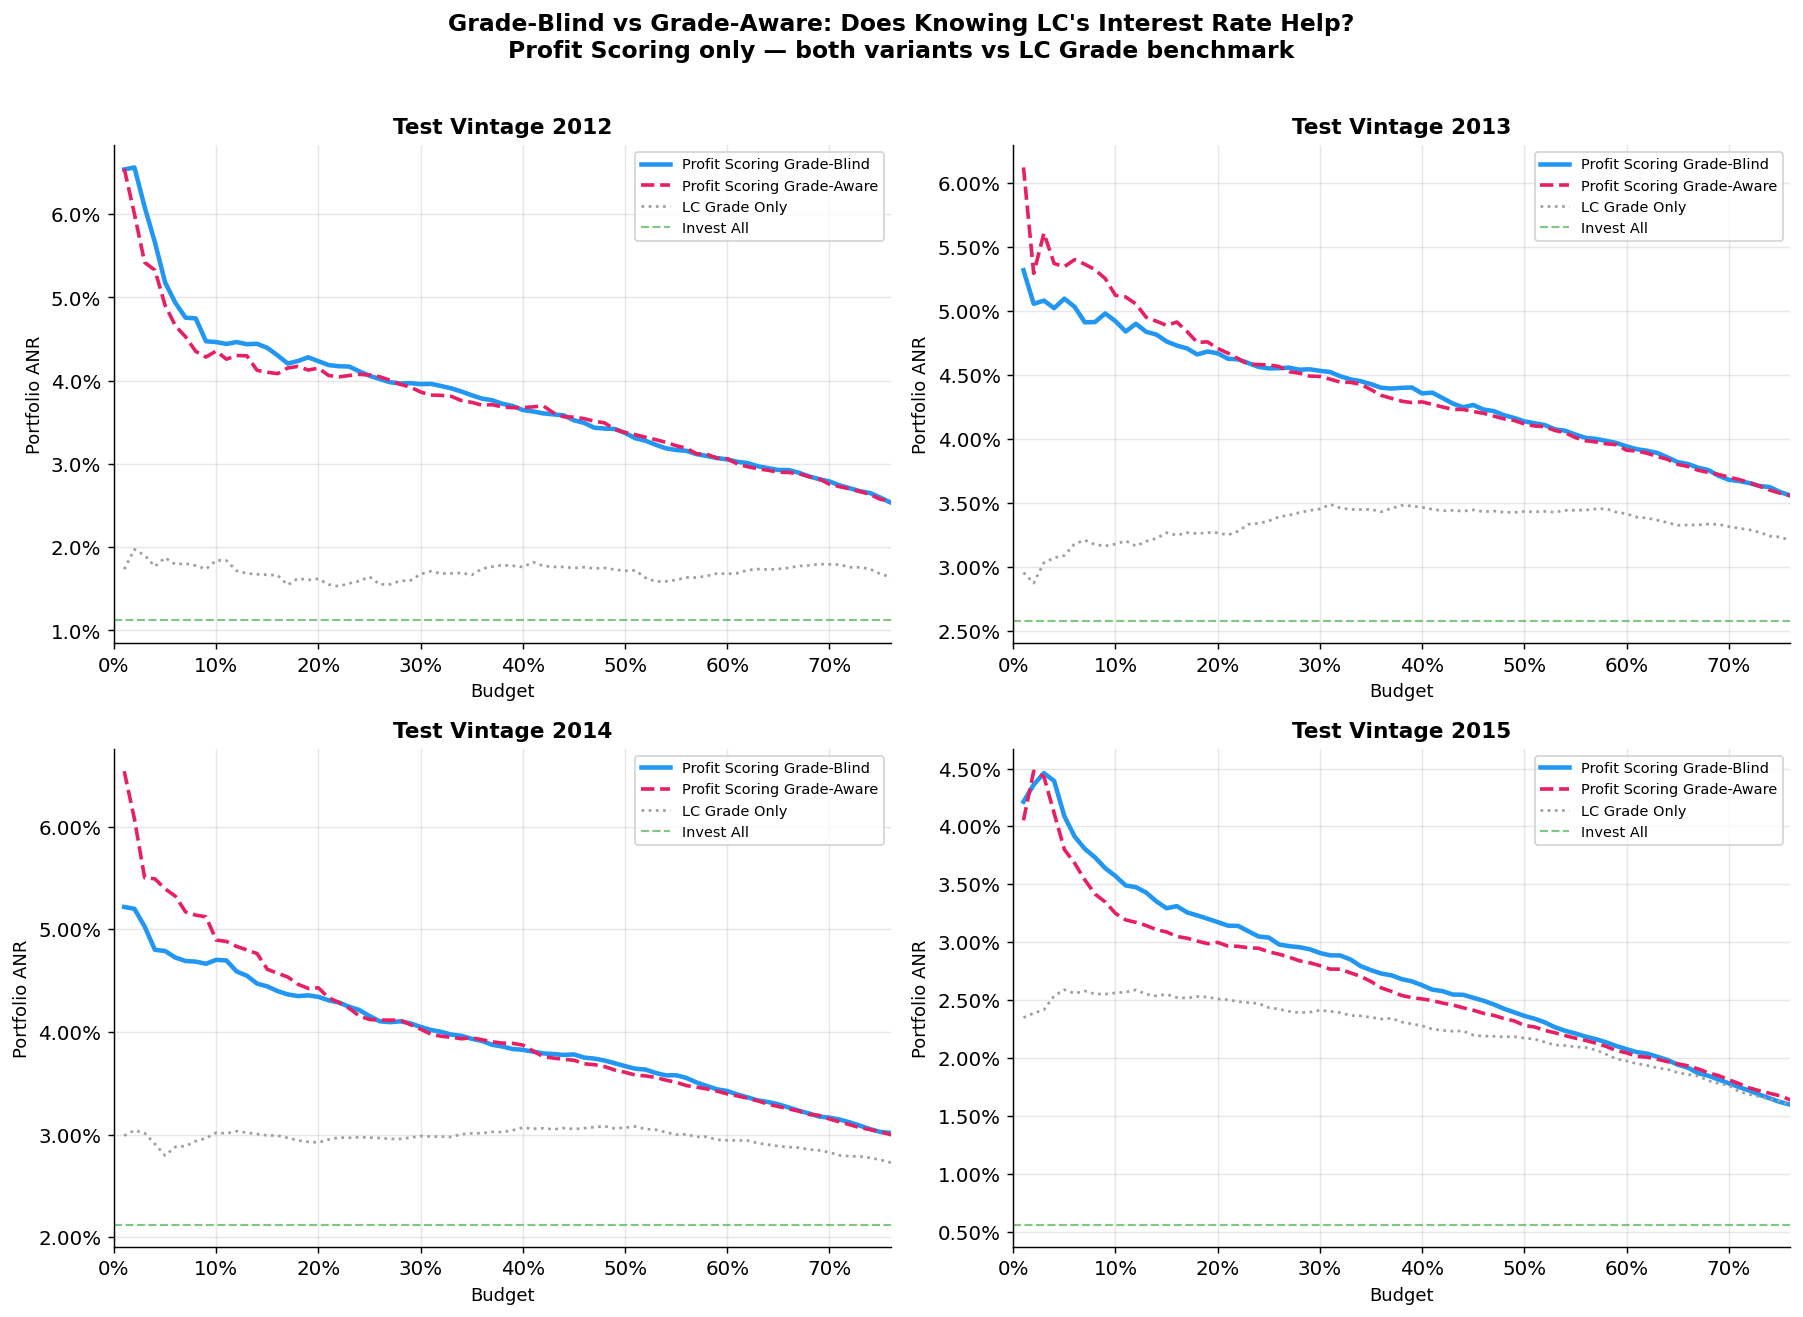

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, year in zip(axes, VINTAGES):
    for variant, ls, lw in [('Grade-Blind', '-', 2.5), ('Grade-Aware', '--', 2.0)]:
        sub = master[(master['vintage']==year) & (master['variant']==variant)]
        ps  = sub[sub['policy']=='profit_scoring']
        if ps.empty:
            continue
        label = f'Profit Scoring {variant}'
        ax.plot(ps['fraction_invested']*100, ps['port_anr']*100,
                color='#2196F3' if variant=='Grade-Blind' else '#E91E63',
                linestyle=ls, linewidth=lw, label=label)

    # grade_only benchmark
    go = master[(master['vintage']==year) & (master['variant']=='Grade-Blind') & (master['policy']=='grade_only')]
    ax.plot(go['fraction_invested']*100, go['port_anr']*100,
            color='#9E9E9E', linewidth=1.5, linestyle=':', label='LC Grade Only')

    ax.axhline(INVEST_ALL_ANR[year]*100, color='#4CAF50', linestyle='--',
               linewidth=1.2, label='Invest All', alpha=0.7)

    ax.set_xlim(0, 76)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Budget', fontsize=10)
    ax.set_ylabel('Portfolio ANR', fontsize=10)
    ax.set_title(f'Test Vintage {year}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Grade-Blind vs Grade-Aware: Does Knowing LC\'s Interest Rate Help?\n'
             'Profit Scoring only — both variants vs LC Grade benchmark',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(REPORTS / 'fig5_grade_blind_vs_aware.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 6: Dollar Uplift at Key Budgets — Summary

Bar chart showing the exact dollar profit advantage of profit scoring over grade-only  
at three fixed budget points: 3%, 25%, and the optimal budget for each vintage.

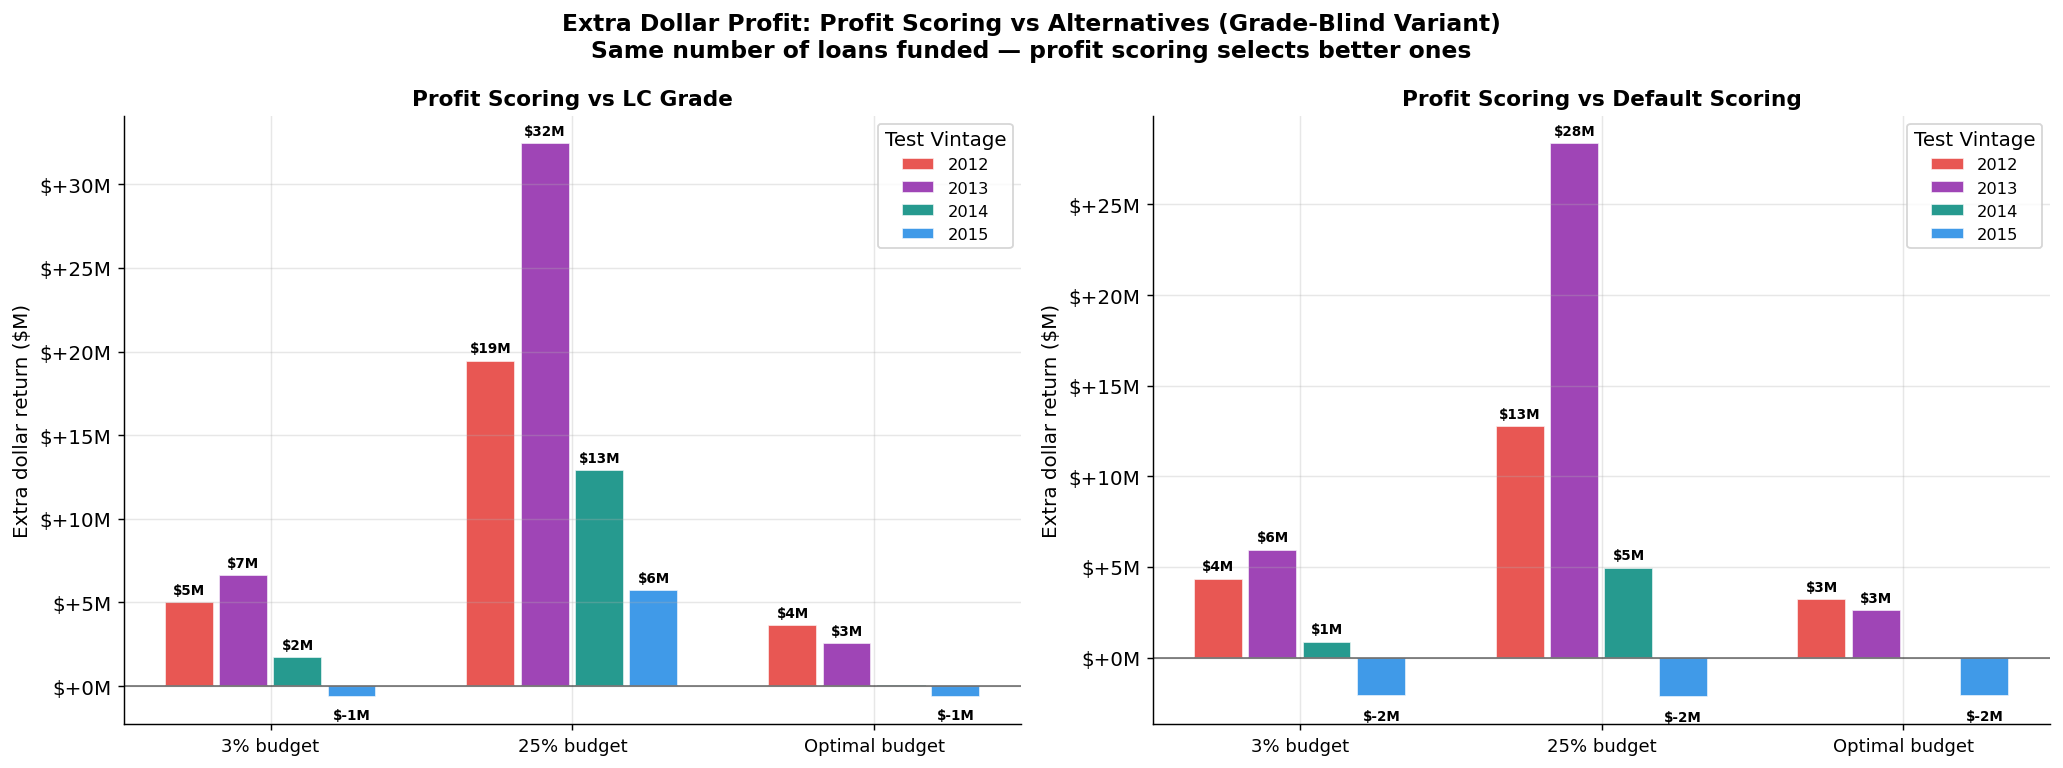

In [9]:
# Compute dollar uplift at 3%, 25%, and optimal for each vintage (Grade-Blind)
OPTIMAL_BUDGETS = {2012: 0.02, 2013: 0.01, 2014: 0.01, 2015: 0.03}

records = []
for year in VINTAGES:
    for budget_label, budget_frac in [('3% budget', 0.03),
                                       ('25% budget', 0.25),
                                       ('Optimal budget', OPTIMAL_BUDGETS[year])]:
        _, ps_dol = get_at(master, year, 'Grade-Blind', 'profit_scoring', budget_frac)
        _, go_dol = get_at(master, year, 'Grade-Blind', 'grade_only',      budget_frac)
        _, ds_dol = get_at(master, year, 'Grade-Blind', 'default_scoring', budget_frac)
        if not any(np.isnan([ps_dol, go_dol])):
            records.append({'vintage': year, 'budget': budget_label,
                            'ps_vs_grade_m': (ps_dol - go_dol) / 1e6,
                            'ps_vs_ds_m':    (ps_dol - ds_dol) / 1e6})

uplift_df = pd.DataFrame(records)

budget_order = ['3% budget', '25% budget', 'Optimal budget']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (col, title) in zip(axes, [
    ('ps_vs_grade_m', 'Profit Scoring vs LC Grade'),
    ('ps_vs_ds_m',    'Profit Scoring vs Default Scoring'),
]):
    n_budgets  = len(budget_order)
    n_vintages = len(VINTAGES)
    bar_w = 0.18
    x = np.arange(n_budgets)

    for i, year in enumerate(VINTAGES):
        vals = []
        for bl in budget_order:
            row = uplift_df[(uplift_df['vintage']==year) & (uplift_df['budget']==bl)]
            vals.append(row[col].values[0] if len(row) else 0)
        offset = (i - n_vintages/2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w*0.9,
                      color=VINTAGE_COLORS[year], label=str(year), alpha=0.85,
                      edgecolor='white')
        for bar, v in zip(bars, vals):
            if abs(v) > 0.5:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + (0.3 if v >= 0 else -1.5),
                        f'${v:.0f}M', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(budget_order, fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:+.0f}M'))
    ax.set_ylabel('Extra dollar return ($M)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Test Vintage', fontsize=9)

fig.suptitle('Extra Dollar Profit: Profit Scoring vs Alternatives (Grade-Blind Variant)\n'
             'Same number of loans funded — profit scoring selects better ones',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'fig6_dollar_uplift_bars.png', bbox_inches='tight', dpi=150)
plt.show()

## Summary Table — All Numbers in One Place

In [10]:
rows = []
for year in VINTAGES:
    for variant in ['Grade-Blind', 'Grade-Aware']:
        for budget_frac, budget_str in [(0.03, '3%'), (0.25, '25%')]:
            ps_anr,  ps_dol  = get_at(master, year, variant, 'profit_scoring',  budget_frac)
            ds_anr,  ds_dol  = get_at(master, year, variant, 'default_scoring', budget_frac)
            go_anr,  go_dol  = get_at(master, year, variant, 'grade_only',      budget_frac)
            ia = INVEST_ALL_ANR[year]
            rows.append({
                'Vintage':           year,
                'Variant':           variant,
                'Budget':            budget_str,
                'Profit Scr ANR':    f'{ps_anr*100:+.2f}%',
                'Default Scr ANR':   f'{ds_anr*100:+.2f}%',
                'Grade-Only ANR':    f'{go_anr*100:+.2f}%',
                'Invest-All ANR':    f'{ia*100:+.2f}%',
                'PS vs Grade (bp)':  f'{(ps_anr-go_anr)*10000:+.0f}',
                'PS vs DS (bp)':     f'{(ps_anr-ds_anr)*10000:+.0f}',
                'PS vs Grade ($M)':  f'${(ps_dol-go_dol)/1e6:+.1f}M',
            })

summary_df = pd.DataFrame(rows)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
summary_df

,Vintage,Variant,Budget,Profit Scr ANR,Default Scr ANR,Grade-Only ANR,Invest-All ANR,PS vs Grade (bp),PS vs DS (bp),PS vs Grade ($M)
0,2012,Grade-Blind,3%,+6.09%,+4.02%,+1.90%,+1.12%,+418,+206,$+5.1M
1,2012,Grade-Blind,25%,+4.06%,+3.31%,+1.65%,+1.12%,+241,+75,$+19.5M
2,2012,Grade-Aware,3%,+5.42%,+2.95%,+1.90%,+1.12%,+352,+247,$+3.9M
3,2012,Grade-Aware,25%,+4.07%,+3.01%,+1.65%,+1.12%,+242,+106,$+16.5M
4,2013,Grade-Blind,3%,+5.08%,+4.36%,+3.03%,+2.58%,+205,+72,$+6.6M
5,2013,Grade-Blind,25%,+4.55%,+4.34%,+3.36%,+2.58%,+119,+21,$+32.4M
6,2013,Grade-Aware,3%,+5.61%,+3.53%,+3.03%,+2.58%,+258,+208,$+12.7M
7,2013,Grade-Aware,25%,+4.58%,+4.19%,+3.36%,+2.58%,+122,+39,$+41.0M
8,2014,Grade-Blind,3%,+5.03%,+4.15%,+3.01%,+2.12%,+201,+88,$+1.7M
9,2014,Grade-Blind,25%,+4.16%,+3.78%,+2.97%,+2.12%,+119,+37,$+12.9M


In [11]:
# Save summary table to CSV
summary_df.to_csv(REPORTS / 'cross_vintage_summary_table.csv', index=False)
print('Summary table saved to reports/cross_vintage_summary_table.csv')

# Key headline numbers
print('\n── Headline numbers (Grade-Blind, profit_scoring) ──')
for year in VINTAGES:
    ps3,  _ = get_at(master, year, 'Grade-Blind', 'profit_scoring', 0.03)
    go3,  _ = get_at(master, year, 'Grade-Blind', 'grade_only',     0.03)
    ps3d, _ = get_at(master, year, 'Grade-Blind', 'profit_scoring', 0.03)
    go3d, d = get_at(master, year, 'Grade-Blind', 'grade_only',     0.03)
    _, ps_dol = get_at(master, year, 'Grade-Blind', 'profit_scoring', 0.03)
    _, go_dol = get_at(master, year, 'Grade-Blind', 'grade_only',     0.03)
    mat = [r[3] for r in FILE_MAP if r[0]==year and r[1]=='Grade-Blind'][0]
    print(f'  {year} ({mat}% matured): PS@3%={ps3*100:+.2f}%  grade@3%={go3*100:+.2f}%  '
          f'advantage={( ps3-go3)*10000:+.0f}bp  extra_dollars=${(ps_dol-go_dol)/1e6:+.1f}M')

Summary table saved to reports/cross_vintage_summary_table.csv

── Headline numbers (Grade-Blind, profit_scoring) ──
  2012 (100% matured): PS@3%=+6.09%  grade@3%=+1.90%  advantage=+418bp  extra_dollars=$+5.1M
  2013 (100% matured): PS@3%=+5.08%  grade@3%=+3.03%  advantage=+205bp  extra_dollars=$+6.6M
  2014 (77% matured): PS@3%=+5.03%  grade@3%=+3.01%  advantage=+201bp  extra_dollars=$+1.7M
  2015 (75% matured): PS@3%=+4.46%  grade@3%=+2.42%  advantage=+204bp  extra_dollars=$-0.6M
